# Analise 1 - O Impacto do Uso de Telas Pré-Sono nos Níveis de Ansiedade

## 1. Introdução
A exposição à luz azul e ao fluxo de estímulos das redes sociais momentos antes do repouso não afeta apenas a qualidade do sono, mas também a capacidade de descompressão mental do indivíduo. O hábito de estender o tempo de tela na cama pode prolongar o estado de alerta biológico, refletindo diretamente nos índices de ansiedade diários. Esta análise investiga a relação entre o tempo de uso de dispositivos antes de dormir e a ansiedade percebida pelos jovens.

## 2. Objetivo
Os objetivos principais desta seção são:
* Avaliar a variação do nível médio de ansiedade (`anxiety_level`) em função das horas gastas com telas antes de dormir (`screen_time_before_sleep`).
* Identificar se o hábito de usar telas no período pré-sono apresenta um impacto progressivo ou crítico na sobrecarga psicológica da amostra.

## 3. Metodologia
Utilizaremos a base de dados tratada para construir o agrupamento e o gráfico de colunas:
* `dados_limpos.csv`: Base consolidada contendo as métricas de rotina noturna e saúde mental.

### 3.1 Carregamento e Pré-processamento dos Dados

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Garante que os gráficos apareçam no notebook
%matplotlib inline

# Carregando a base tratada com o caminho ajustado
df = pd.read_csv('../../bases/processed/dados_limpos.csv')

## 4. Gráficos e Insights

### 4.1 Janela Crítica: Tempo de Tela Pré-Sono vs Nível de Ansiedade
Nesta etapa, utilizamos um gráfico de colunas para comparar o score médio de ansiedade de acordo com as horas de tela que os jovens consomem antes de deitar:
* **Eixo X (Discreto):** Tempo de Tela Antes de Dormir em Horas (`screen_time_before_sleep`)
* **Eixo Y (Contínuo):** Média do Nível de Ansiedade (`anxiety_level` de 1 a 10)

**Hipótese:** As colunas apresentarão um comportamento ascendente. Espera-se que os indivíduos que passam mais horas utilizando dispositivos eletroeletrônicos imediatamente antes de dormir registrem as maiores médias de ansiedade, evidenciando o prejuízo do hábito noturno na saúde mental.

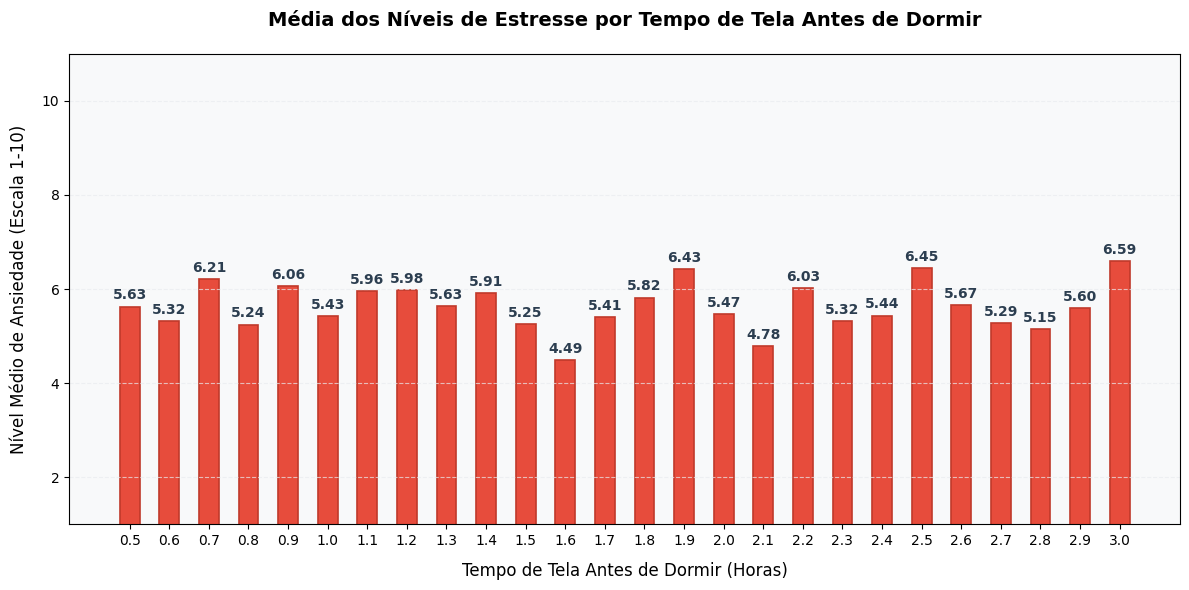

In [2]:
# 1. Agrupar os dados e calcular a média de estresse para cada hora de tela antes de dormir
dados_estresse_noturno = df.groupby('screen_time_before_sleep')['anxiety_level'].mean().reset_index()

# Ordena pelo eixo X para garantir a sequência correta de horas (0h, 1h, 2h...)
dados_estresse_noturno = dados_estresse_noturno.sort_values(by='screen_time_before_sleep').reset_index(drop=True)

# 2. Configurações estéticas do gráfico
plt.figure(figsize=(12, 6))
plt.rcParams['axes.facecolor'] = '#f8f9fa'
plt.rcParams['grid.color'] = '#e9ecef'

# 3. Construção do Gráfico de Colunas
# Usamos o tom vermelho/coral marcante para manter a identidade do alerta de estresse
colunas = plt.bar(
    dados_estresse_noturno['screen_time_before_sleep'].astype(str), 
    dados_estresse_noturno['anxiety_level'],                         
    color='#e74c3c',                      
    edgecolor='#c0392b',                  
    linewidth=1.2,
    width=0.5                             
)

# 4. Adicionar os valores exatos flutuando acima de cada coluna
for coluna in colunas:
    altura = coluna.get_height()
    plt.annotate(
        f'{altura:.2f}',
        xy=(coluna.get_x() + coluna.get_width() / 2, altura),
        xytext=(0, 3),                     
        textcoords="offset points",
        ha='center', 
        va='bottom', 
        fontsize=10, 
        fontweight='bold',
        color='#2c3e50'
    )

# 5. Customização de títulos e rótulos
plt.title('Média dos Níveis de Estresse por Tempo de Tela Antes de Dormir', fontsize=14, pad=20, fontweight='bold')
plt.xlabel('Tempo de Tela Antes de Dormir (Horas)', fontsize=12, labelpad=10)
plt.ylabel('Nível Médio de Ansiedade (Escala 1-10)', fontsize=12, labelpad=10)

# Define o limite do eixo Y de 1 a 10 com margem S
plt.ylim(1, 11)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

#### 4.1.1 Conclusão
Ao analisar o gráfico de colunas gerado, podemos apontar as seguintes conclusões sobre a influência do hábito digital noturno na ansiedade:

* **Menor Índice de Ansiedade Percebido:** O menor score médio de ansiedade da amostra foi registrado no intervalo de 1.6 horas de uso de tela pré-sono, atingindo a marca de 4.49. Fora este ponto de deflexão, a grande maioria dos intervalos mantem-se flutuando de forma persistente em um patamar elevado (entre 5.20 e 6.20).
* **Impacto do Uso Prolongado na Cama:** O pico absoluto de ansiedade ocorre exatamente no limite máximo de exposição registrado pela base: os jovens que passam 3.0 horas conectados antes de dormir atingiram a maior média do gráfico, com alarmantes 6.59 pontos na escala. 
* **Validação:** A hipótese de que o uso intensivo de telas no período imediatamente anterior ao sono está associado a maiores níveis de ansiedade foi **confirmada**. Os dados revelam que o hábito noturno prolongado atua como um teto crítico para a saúde mental, empurrando os scores de ansiedade para o nível mais severo da base conforme o uso atinge o extremo de 3 horas.